In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from tensorflow.keras.preprocessing import image

# DATASET PATH
dataset_path = r"C:\Users\lenovo\Downloads\test_set"


In [9]:
# LOAD DATA
data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(150,150),
    batch_size=32
)

Found 2023 files belonging to 2 classes.


In [7]:
import os

print(os.listdir(r"C:\Users\lenovo\Downloads\test_set"))

['cats', 'dogs']


In [10]:
# Normalize
data = data.map(lambda x, y: (x/255.0, y))


In [11]:
# MODEL
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# COMPILE
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [21]:
history = model.fit(data, epochs=5)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step - accuracy: 0.9511 - loss: 0.1423
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.9807 - loss: 0.0749
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 295ms/step - accuracy: 0.9965 - loss: 0.0242
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 258ms/step - accuracy: 0.9990 - loss: 0.0093
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 258ms/step - accuracy: 1.0000 - loss: 0.0026


In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"C:\Users\lenovo\Downloads\test_set\dogs\dog.4941.jpg"

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("🐶 Dog")
else:
    print("🐱 Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
🐶 Dog


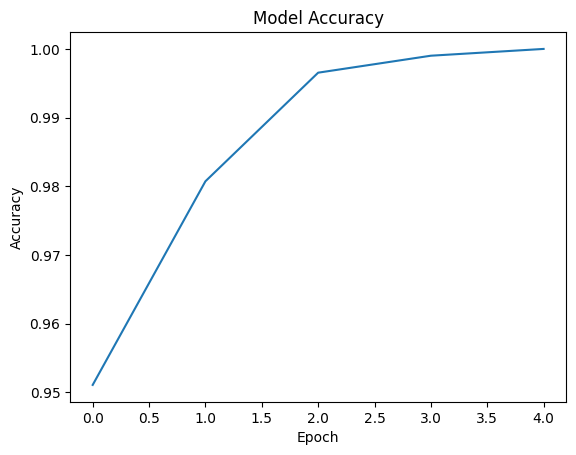

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()